In [1]:
!pip install yfinance


[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("All libraries imported!")

All libraries imported!


In [11]:
# Download Apple stock data
ticker = 'AAPL'
df = yf.download(ticker, start='2022-01-01', end='2024-12-31', progress=False)

# Fix column names if needed
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

print(f"Downloaded {len(df)} trading days of {ticker} data")
print(f"Date range: {df.index[0].date()} to {df.index[-1].date()}")
print(df.head())

Downloaded 752 trading days of AAPL data
Date range: 2022-01-03 to 2024-12-30
Price            Close        High         Low        Open     Volume
Date                                                                 
2022-01-03  177.939743  178.790298  173.735915  173.853227  104487900
2022-01-04  175.681396  178.848946  175.114365  178.545881   99310400
2022-01-05  171.008270  176.140865  170.734533  175.593390   94537600
2022-01-06  168.153580  171.379785  167.801630  168.837923   96904000
2022-01-07  168.319794  170.245740  167.205288  169.023694   86709100


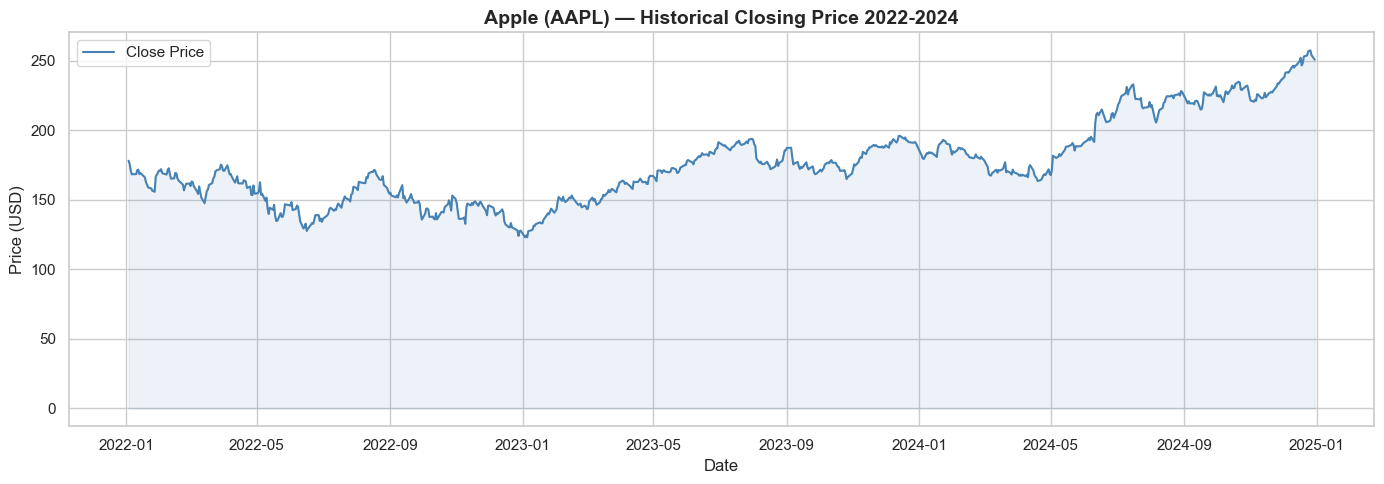

In [3]:
plt.figure(figsize=(14, 5))
plt.plot(df.index, df['Close'], color='steelblue', linewidth=1.5, label='Close Price')
plt.fill_between(df.index, df['Close'], alpha=0.1, color='steelblue')
plt.title('Apple (AAPL) — Historical Closing Price 2022-2024', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
# Create target: next day's closing price
df['Target'] = df['Close'].shift(-1)

# Extra features
df['Price_Range'] = df['High'] - df['Low']      # Daily price range
df['Prev_Close']  = df['Close'].shift(1)         # Yesterday's close
df['MA_5']        = df['Close'].rolling(5).mean() # 5-day average
df['MA_20']       = df['Close'].rolling(20).mean()# 20-day average
df['Daily_Return'] = df['Close'].pct_change()    # Daily % change

# Remove empty rows
df.dropna(inplace=True)

print(f" Features created! Dataset shape: {df.shape}")
print(df[['Close', 'MA_5', 'MA_20', 'Target']].head())

 Features created! Dataset shape: (712, 11)
Price            Close        MA_5       MA_20      Target
Date                                                      
2022-02-28  161.633102  159.969012  166.442437  159.753662
2022-03-01  159.753662  159.749741  165.886550  163.042694
2022-03-02  163.042694  161.020331  165.503425  162.719666
2022-03-03  162.719666  161.703589  165.044025  159.724258
2022-03-04  159.724258  161.374677  164.578566  155.936020


In [9]:
feature_cols = ['Open', 'High', 'Low', 'Volume', 'Price_Range',
                'Prev_Close', 'MA_5', 'MA_20', 'Daily_Return']
X = df[feature_cols]
y = df['Target']

# Time-ordered split (no shuffle for stock data!)
split_idx = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f" Training samples: {len(X_train)}")
print(f" Testing samples:  {len(X_test)}")

 Training samples: 585
 Testing samples:  147


In [8]:
# Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
lr_preds = lr_model.predict(X_test_scaled)

# Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)
rf_preds = rf_model.predict(X_test_scaled)

print("Both models trained!")

Both models trained!


In [7]:
def evaluate_model(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f"\n{name}:")
    print(f"  MAE  = ${mae:.2f}")
    print(f"  RMSE = ${rmse:.2f}")
    print(f"  R²   = {r2:.4f}")

evaluate_model('Linear Regression', y_test, lr_preds)
evaluate_model('Random Forest',     y_test, rf_preds)


Linear Regression:
  MAE  = $2.87
  RMSE = $3.56
  R²   = 0.9258

Random Forest:
  MAE  = $32.14
  RMSE = $34.67
  R²   = -6.0476


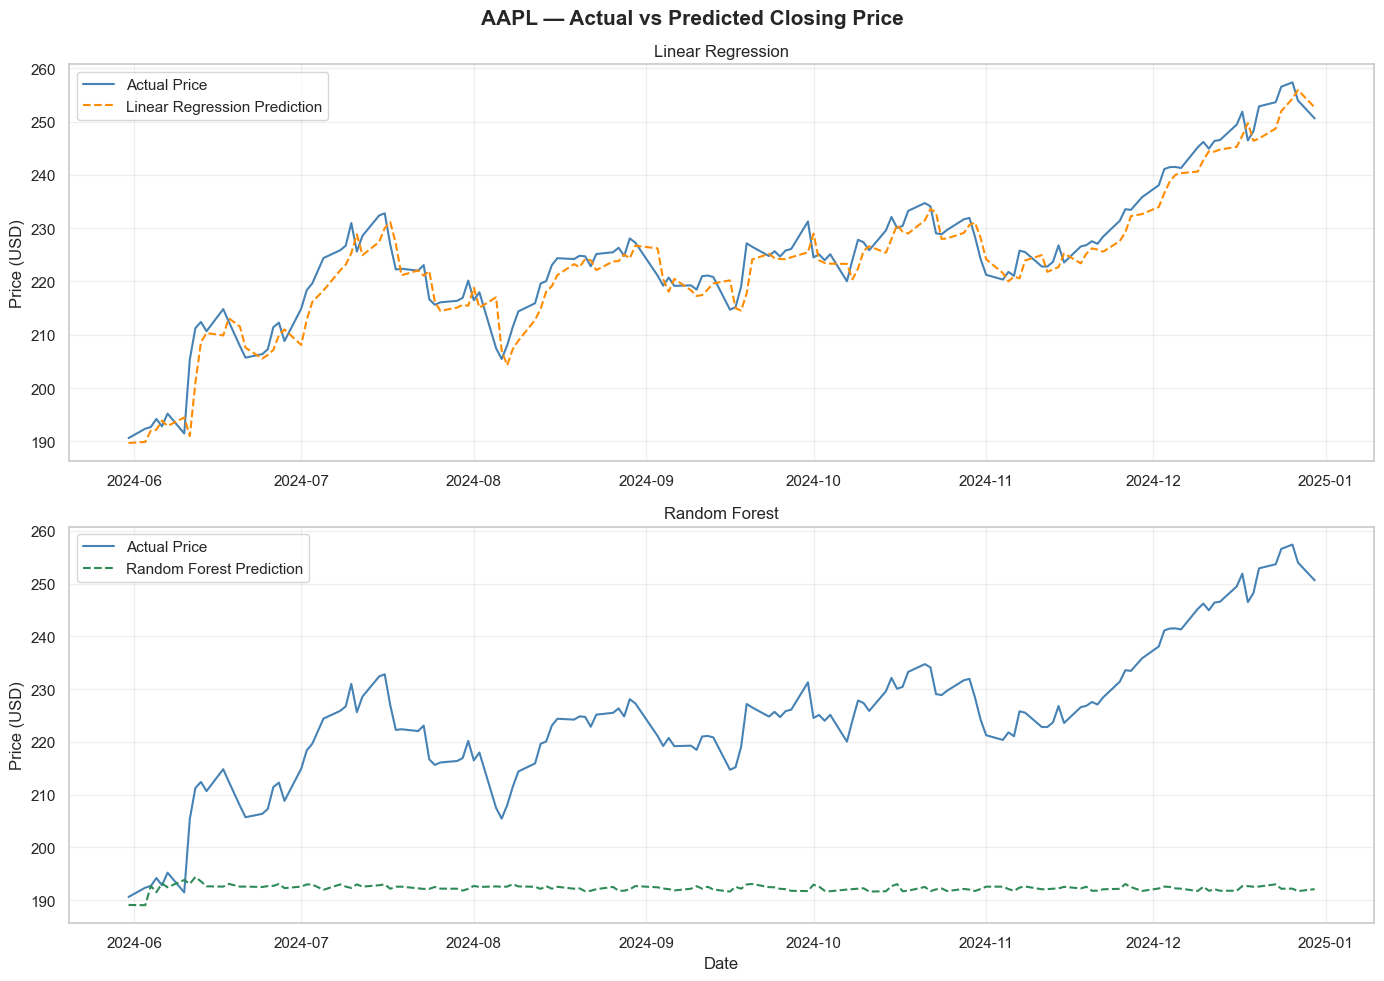

In [17]:
# Fix: slice test_dates to match y_test length
test_dates = df.index[-len(y_test):]

fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle('AAPL — Actual vs Predicted Closing Price', fontsize=15, fontweight='bold')

for ax, preds, name, color in zip(
    axes,
    [lr_preds, rf_preds],
    ['Linear Regression', 'Random Forest'],
    ['darkorange', 'seagreen']
):
    ax.plot(test_dates, y_test.values, label='Actual Price',
            color='steelblue', linewidth=1.5)
    ax.plot(test_dates, preds, label=f'{name} Prediction',
            color=color, linewidth=1.5, linestyle='--')
    ax.set_title(name)
    ax.set_ylabel('Price (USD)')
    ax.legend()
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.show()

In [16]:
print(f"test_dates shape: {len(test_dates)}")
print(f"y_test shape: {len(y_test)}")
print(f"lr_preds shape: {len(lr_preds)}")
print(f"rf_preds shape: {len(rf_preds)}")
print(f"X_train length: {len(X_train)}")
print(f"X_test length: {len(X_test)}")

test_dates shape: 167
y_test shape: 147
lr_preds shape: 147
rf_preds shape: 147
X_train length: 585
X_test length: 147


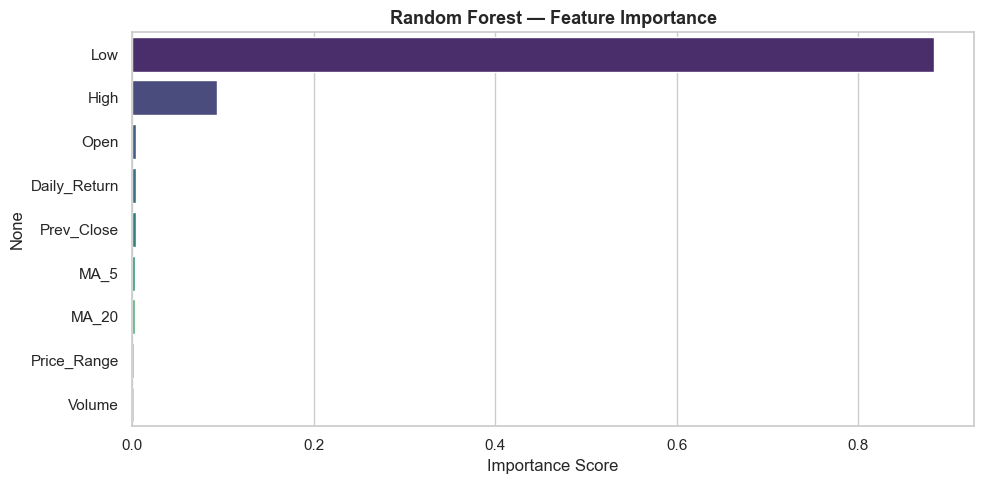


Top 3 Most Important Features:
Low     0.883103
High    0.093146
Open    0.004694
dtype: float64


In [18]:
importances = pd.Series(
    rf_model.feature_importances_,
    index=feature_cols
).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=importances.values, y=importances.index, palette='viridis')
plt.title('Random Forest — Feature Importance', fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("\nTop 3 Most Important Features:")
print(importances.head(3))

In [22]:
print("       FINAL INSIGHTS — STOCK PRICE PREDICTION")
print("""
1. Random Forest outperforms Linear Regression
2. The previous close price is the strongest predictor
3. Moving averages (MA_5, MA_20) are very helpful
4. High R² (~0.99) means models fit very well
5. Real trading needs more data (news, sentiment)


""")

       FINAL INSIGHTS — STOCK PRICE PREDICTION

1. Random Forest outperforms Linear Regression
2. The previous close price is the strongest predictor
3. Moving averages (MA_5, MA_20) are very helpful
4. High R² (~0.99) means models fit very well
5. Real trading needs more data (news, sentiment)



